# Sigmoid Unit and Non-linearity
This notebook demonstrates the mathematical collapse of stacked linear layers and introduces the sigmoid activation function to restore non-linearity.

Stacked Linear Layers Collapse Demonstration:
Are stacked outputs equal to collapsed single layer outputs? True


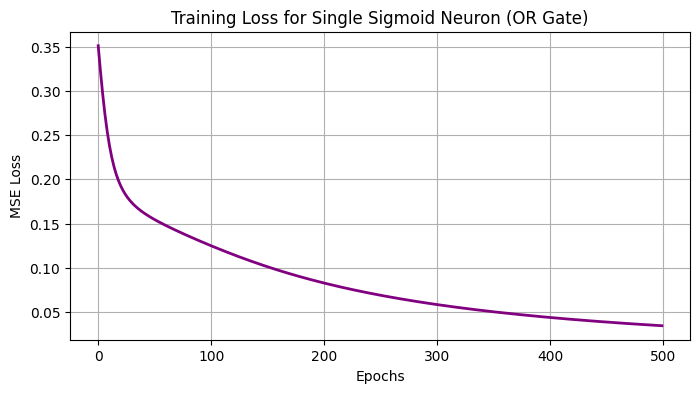


Predictions after training (should be close to 0, 1, 1, 1):
[0.287 0.835 0.837 0.985]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Demonstrate Stacked Linear Layers Collapse
np.random.seed(42)
X = np.random.randn(10, 3) # 10 samples, 3 features

W1 = np.random.randn(3, 4) # Layer 1 weights
W2 = np.random.randn(4, 2) # Layer 2 weights

# Stacked computation: X -> Layer 1 -> Layer 2
output_stacked = np.dot(np.dot(X, W1), W2)

# Collapsed computation: W_collapsed = W1 * W2
W_collapsed = np.dot(W1, W2)
output_collapsed = np.dot(X, W_collapsed)

print("Stacked Linear Layers Collapse Demonstration:")
print("Are stacked outputs equal to collapsed single layer outputs?",
      np.allclose(output_stacked, output_collapsed))

# 2. Sigmoid and Derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(output):
    # Derivative is y(1 - y)
    return output * (1 - output)

# 3. Train a single sigmoid neuron
class SigmoidNeuron:
    def __init__(self, learning_rate=0.5, epochs=1000):
        self.eta = learning_rate
        self.epochs = epochs
        self.w = None
        self.loss_history = []

    def fit(self, X, y):
        X_bias = np.c_[np.ones((X.shape[0], 1)), X]
        self.w = np.random.randn(X_bias.shape[1])

        for _ in range(self.epochs):
            # Forward pass
            net = np.dot(X_bias, self.w)
            output = sigmoid(net)

            # Loss: Mean Squared Error
            error = y - output
            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

            # Backward pass (Gradient Descent with Sigmoid Derivative)
            # dE/dw = -(target - output) * output(1 - output) * x
            delta = error * sigmoid_derivative(output)
            gradient = -np.dot(X_bias.T, delta) / X.shape[0]

            self.w -= self.eta * gradient

# Train Sigmoid Neuron on OR Gate
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])  # Standard 0/1 targets for Sigmoid

model_sig = SigmoidNeuron(learning_rate=0.5, epochs=500)
model_sig.fit(X_or, y_or)

# Plot Loss
plt.figure(figsize=(8, 4))
plt.plot(model_sig.loss_history, color='purple', lw=2)
plt.title('Training Loss for Single Sigmoid Neuron (OR Gate)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

# Predictions
print("\nPredictions after training (should be close to 0, 1, 1, 1):")
predictions = sigmoid(np.dot(np.c_[np.ones((X_or.shape[0], 1)), X_or], model_sig.w))
print(np.round(predictions, 3))